## Donald Bango
## Recurrent Neural Network (AAPL Predictions - LSTM)
## 5 June 2024
## Dr. Ali Wahid

## Dataset Description

## Problem Statement

The goal of this project is to build a Long Short-Term Memory (LSTM) model to predict the stock price of Apple Inc. (AAPL) for the year 2021 using historical stock price data. Additionally, we aim to evaluate the model's ability to predict stock prices for the year 2022. This study seeks to forecast future prices and explore how these predictions can potentially assist in financial planning and investment strategies. By accurately predicting stock prices, investors can potentially increase returns and reduce risks associated with market volatility and gain a better understanding of the factors that may affect a stock's value.

## Why Use LSTMs for Predicting Stock Prices?

LSTMs excel in financial time series forecasting with their ability to handle sequence data, memory capacity, and ability to learn complex temporal patterns. These models capture trends, cycles, and volatility, utilizing past data to predict future movements. This capability is impactful for predicting stock prices.

## Solution Algorithm

1. Data Collection: Fetch historical stock price data for Apple Inc. using the Yahoo Finance API, which provides access to daily stock prices and trading volumes.

2. Data Preprocessing: Normalize the data using MinMaxScaler to scale the 'Close' prices between 0 and 1. This normalization helps in stabilizing the training process of the LSTM by keeping input numerical values within a standard range.

3. Creating Sequences: Generate sequences of 60 days of stock prices, which are used to predict the following day's price. This sequence length helps the model in learning patterns over two months of trading days.

4. Model Building: Construct an LSTM network with dropout layers to prevent overfitting, ensuring that the model generalizes well to unseen data.

5. Model Training: Train the model for 75 epochs with a batch size of 32. Use a validation split to monitor the model's performance on unseen data during training.

6. Model Evaluation: Assess the model using RMSE to quantify the average prediction error in the stock prices, which directly correlates with investment risk.

7. Predicting Future Prices: Utilize the trained model to forecast stock prices for the year 2022, analyzing the model's ability to generalize beyond the training data.


In [124]:
%%capture

# Install necessary packages
%pip install yfinance tensorflow numpy matplotlib

# Import required libraries
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose



### Import Dataset

In [125]:
# Retrieve historical stock data from Yahoo Finance for Apple (AAPL) from 2010 to 2022
apple_data = yf.download('AAPL', start='2010-01-01', end='2022-12-31')

[*********************100%%**********************]  1 of 1 completed


### Exploratory Data Analysis

In [126]:
print(apple_data.head(10))

                Open      High       Low     Close  Adj Close     Volume
Date                                                                    
2010-01-04  7.622500  7.660714  7.585000  7.643214   6.461975  493729600
2010-01-05  7.664286  7.699643  7.616071  7.656429   6.473148  601904800
2010-01-06  7.656429  7.686786  7.526786  7.534643   6.370184  552160000
2010-01-07  7.562500  7.571429  7.466071  7.520714   6.358409  477131200
2010-01-08  7.510714  7.571429  7.466429  7.570714   6.400680  447610800
2010-01-11  7.600000  7.607143  7.444643  7.503929   6.344218  462229600
2010-01-12  7.471071  7.491786  7.372143  7.418571   6.272049  594459600
2010-01-13  7.423929  7.533214  7.289286  7.523214   6.360521  605892000
2010-01-14  7.503929  7.516429  7.465000  7.479643   6.323685  432894000
2010-01-15  7.533214  7.557143  7.352500  7.354643   6.218003  594067600


In [127]:
# Dataset Info
apple_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3272 entries, 2010-01-04 to 2022-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       3272 non-null   float64
 1   High       3272 non-null   float64
 2   Low        3272 non-null   float64
 3   Close      3272 non-null   float64
 4   Adj Close  3272 non-null   float64
 5   Volume     3272 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 178.9 KB


In [128]:
# Descriptive statistics
print(apple_data.describe())

              Open         High          Low        Close    Adj Close  \
count  3272.000000  3272.000000  3272.000000  3272.000000  3272.000000   
mean     51.297746    51.869747    50.731996    51.321186    49.065502   
std      47.328490    47.938843    46.732224    47.357062    47.433208   
min       6.870357     7.000000     6.794643     6.858929     5.798900   
25%      18.966697    19.121697    18.780179    18.967589    16.490458   
50%      29.756250    29.981250    29.561250    29.815000    27.162603   
75%      56.983748    57.309999    56.469999    56.777499    54.504434   
max     182.630005   182.940002   179.119995   182.009995   179.481094   

             Volume  
count  3.272000e+03  
mean   2.562707e+08  
std    2.225648e+08  
min    3.519590e+07  
25%    1.023541e+08  
50%    1.666698e+08  
75%    3.456643e+08  
max    1.880998e+09  


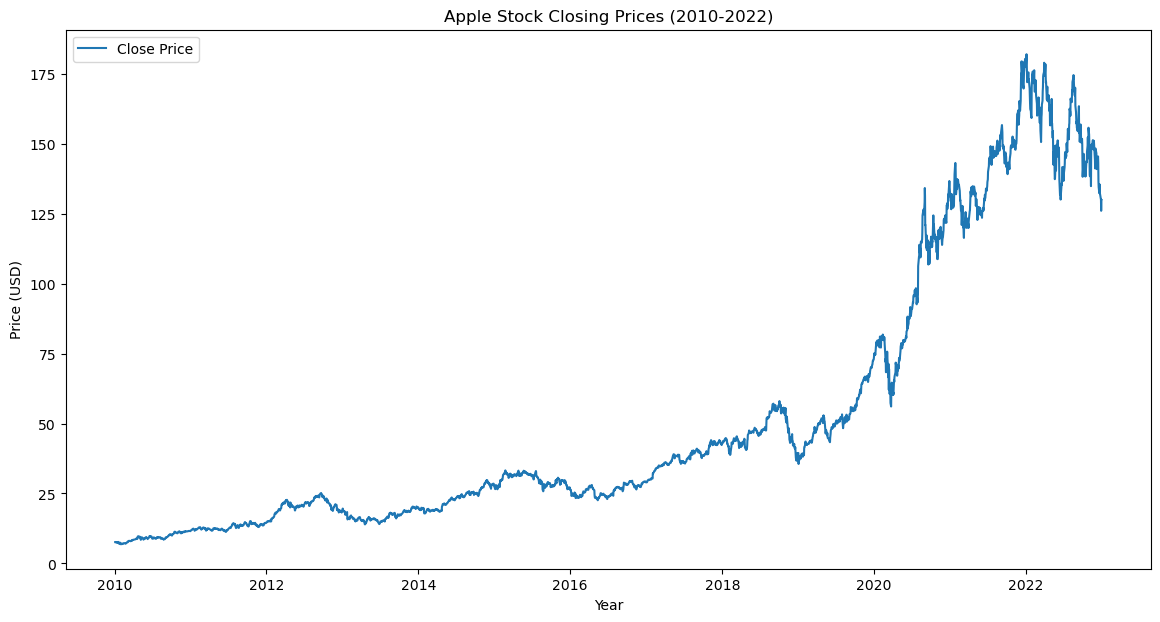

In [129]:
plt.figure(figsize=(14, 7))
plt.plot(apple_data['Close'], label='Close Price')
plt.title('Apple Stock Closing Prices (2010-2022)')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


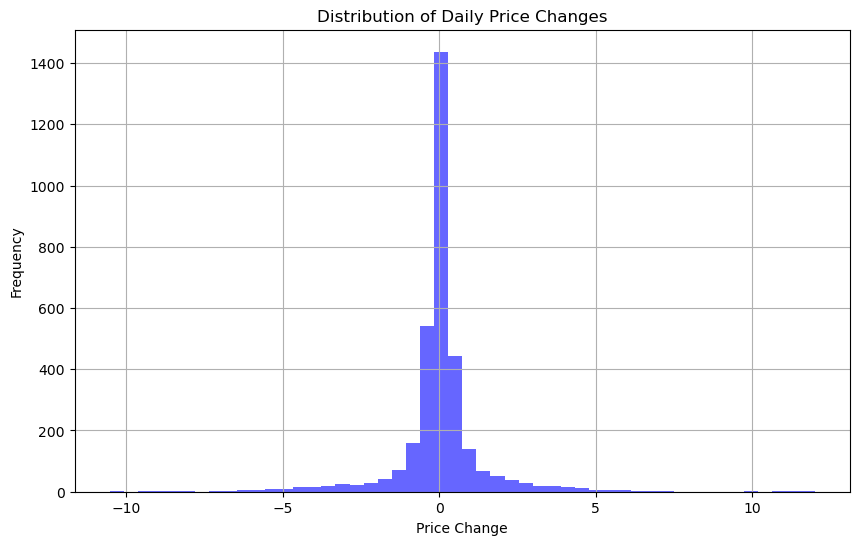

In [130]:
# daily price changes
apple_data['Daily Change'] = apple_data['Close'].diff()

plt.figure(figsize=(10, 6))
apple_data['Daily Change'].plot(kind='hist', bins=50, alpha=0.6, color='blue')
plt.title('Distribution of Daily Price Changes')
plt.xlabel('Price Change')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


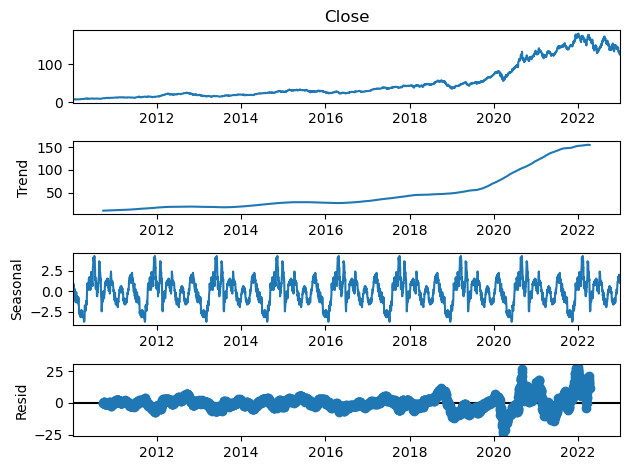

In [131]:
# Decompose the closing price to trend, seasonal, and residual components
result = seasonal_decompose(apple_data['Close'].dropna(), model='additive', period=365)
result.plot()
plt.show()


EDA Observation: From the EDA, there was a noticeable increase in stock price volatility after the first quarter of 2020. This could pose a challenge for the model in predicting prices accurately for the subsequent years up to 2022 due to sudden changes in stock movement.


***Preprocess the data:***

Scale and create sequences for LSTM model input


In [132]:
# Selecting the 'Close' price as the feature
data = apple_data['Close'].values.reshape(-1, 1)

In [133]:
data.shape

(3272, 1)

In [134]:
# Scaling the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data) # Normalize the 'Close' prices


Normalizing data to a range between 0 and 1, using MinMax Scaling for preventing bias towards higher magnitude features and achieving faster convergence in the neural networks. All input features contribute equally to the analysis.

In [135]:
# Define a function to create sequences from the data

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length]) # Append the sequence to the features list
        y.append(data[i+seq_length]) # Append the next day price to the labels list
    return np.array(X), np.array(y) # Return numpy arrays of the features and labels

seq_length = 60 # Number of days in sequence window
X, y = create_sequences(scaled_data, seq_length)

In [136]:
# Splitting the dataset into training and testing sets to avoid overfitting. (Is this needed?)
split = int(0.8 * len(X))  # 80% of the data for training

X_train, X_test = X[:split], X[split:]  # Feature splits
y_train, y_test = y[:split], y[split:]  # Label splits


Features (X): These are the sequences of past stock prices.

Labels (y): These are the subsequent stock prices that immediately follow each sequence. 

How Sequences Are Structured for LSTM:
Length of Sequence: The length of each sequence, the window, is a parameter. A sequence length of 60 means each input sequence for the LSTM will include the stock prices from 60 consecutive days.

Data in a Sequence: Each sequence consists of historical daily stock prices leading up to a specific day. The sequence ends the day before the price we want to predict. For example, if we want to predict the stock price for January 61st, the sequence would include prices from Day 1 to Day 60.

Shifting Window: To create multiple training examples, we include a sliding window approach. After forming the first sequence from Day 1 to Day 60, the next sequence might start from Day 2 and end on Day 61, and so on. This way, you can utilize all available data efficiently, creating overlapping sequences that share many of the same data points but shift one period forward for each new sequence.

In [137]:
# Reshaping the data for LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

We have now reshaped the data into the following format (#values, #time-steps, #1-dimensional output).

In [138]:
X_train.shape

(2569, 60, 1)

In [139]:
# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),  # First LSTM layer with 50 neurons in each LSTM layer, returns sequences for next layer
    Dropout(0.2),  # Dropout for regularization, prevents overfitting.
    LSTM(50, return_sequences=False),  # Second LSTM layer. returns last output for making final prediction
    Dropout(0.2),  # Additional dropout. (regularization)
    Dense(1)  # Output layer with one neuron to make predictions
])

model.compile(optimizer='adam', loss='mean_squared_error')  # Compile the model using Adam optimizer and MSE loss


In [140]:
model.summary()  # Print the summary, showing layers and parameters

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [141]:
#%%capture

# Training the LSTM model with 75 epochs.
history = model.fit(X_train, y_train, epochs=75, batch_size=32, validation_split=0.2)


Epoch 1/75
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0027 - val_loss: 4.4305e-04
Epoch 2/75
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.4591e-04 - val_loss: 3.8864e-04
Epoch 3/75
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.4223e-04 - val_loss: 3.5283e-04
Epoch 4/75
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.1266e-04 - val_loss: 2.5906e-04
Epoch 5/75
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.1315e-04 - val_loss: 2.5784e-04
Epoch 6/75
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.6930e-05 - val_loss: 5.0708e-04
Epoch 7/75
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.9421e-05 - val_loss: 2.3028e-04
Epoch 8/75
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8.9012e-05 - val_loss: 2.7156e-04
Epoch 9/75
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8.7070e-05 - val_loss: 2.1055e-04
Epoch 10/75
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.0650e-05 - val_loss: 2.1792e-04
Epoch 11/75
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 6.8524e-05 - 

In [142]:
# Making predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)


81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [143]:
# Inverting the scaling to transform the predicted values back to their original scale
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
actual_prices = scaler.inverse_transform(scaled_data[seq_length:])


### Evaluate the Model

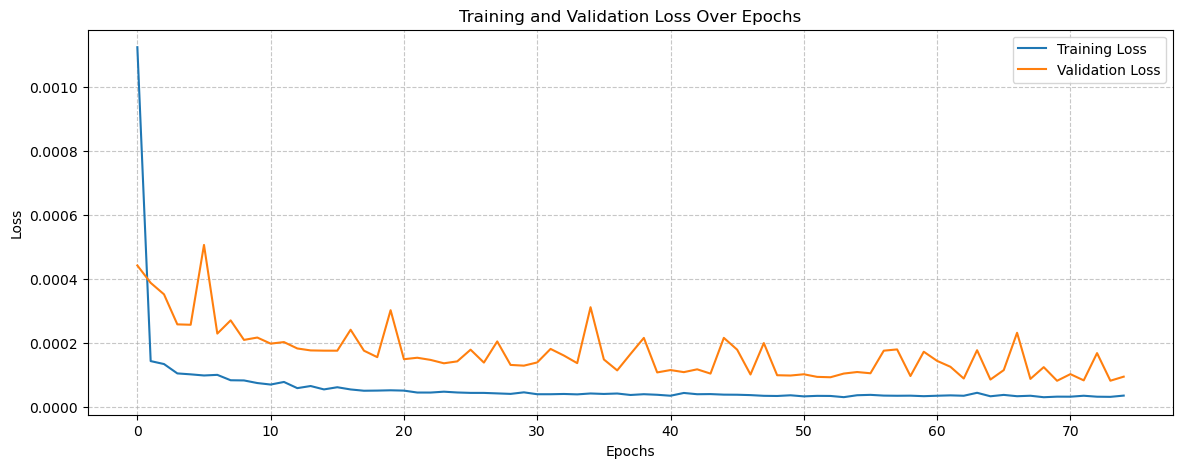

In [144]:
# Plotting the training and validation loss
plt.figure(figsize=(14, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

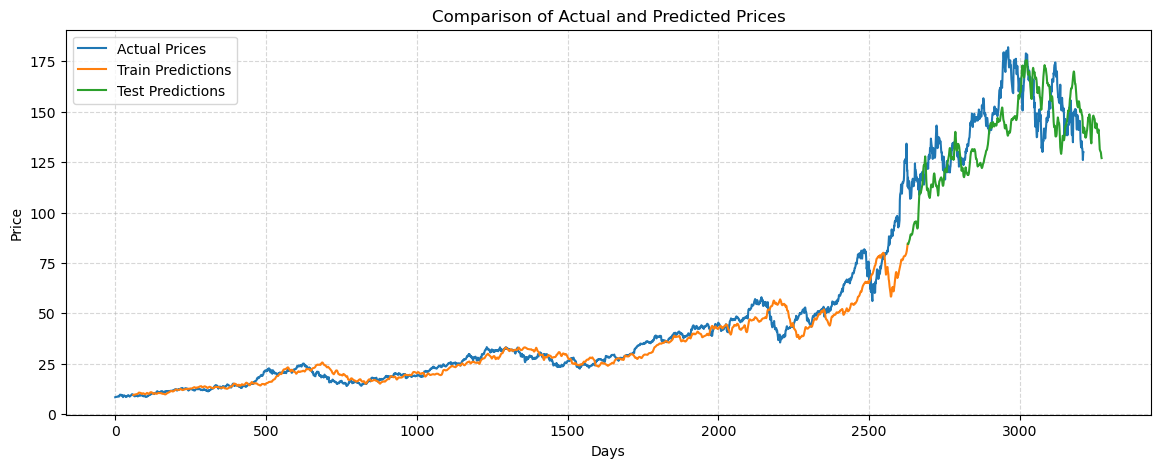

In [145]:
# Plotting the results
plt.figure(figsize=(14, 5))
plt.plot(actual_prices, label='Actual Prices')
plt.plot(range(seq_length, seq_length+len(train_predict)), train_predict, label='Train Predictions')
plt.plot(range(seq_length+len(train_predict), seq_length+len(train_predict)+len(test_predict)), test_predict, label='Test Predictions')
plt.title('Comparison of Actual and Predicted Prices')  # Add a title to the plot
plt.xlabel('Days')  # Label for the x-axis
plt.ylabel('Price')  # Label for the y-axis
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


## Interpretatiion for model performace for the calnder year 2021

***Trend Prediction:***

The LSTM model successfully identifies and follows the overall trends in stock prices, indicating its ability to learn from historical data and detect underlying patterns. This is evident in how the predicted prices (both train and test) move in the same direction as the actual prices.

***Lag in Predictions:***

A notable issue is the lag in the model’s predictions. The predicted prices appear to be consistently delayed compared to the actual prices. This lag suggests that the model is using past information effectively but struggles to anticipate sudden changes or shifts in the stock prices promptly.

***Underestimation:***

The model tends to predict values that are generally lower than the actual stock prices. This consistent underestimation might indicate a bias in the model, where it is more conservative in its predictions. This can be particularly problematic in a volatile market where capturing the exact peaks and troughs is crucial for accurate forecasting.

***Conclusion***

The LSTM model demonstrates its capability to capture the general trends and patterns of the stock prices, as observed from the comparison graph between actual and predicted prices for 2021. However, there appears to be limitations that impact the accuracy of the predictions.

In [165]:
# Calculating RMSE
#train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))
#test_rmse = np.sqrt(mean_squared_error(y_test, test_predict))

#print(f'Train RMSE: {train_rmse:.3f}')
#print(f'Test RMSE: {test_rmse:.3f}')


# Calculate Mean Absolute Error (MAE)
#train_mae = mean_absolute_error(y_train, train_predict)
#test_mae = mean_absolute_error(y_test, test_predict)

#print(f'Train MAE: {train_mae:.3f}')
#print(f'Test MAE: {test_mae:.3f}')

# Calculate Mean Absolute Percentage Error (MAPE)
#train_mape = mean_absolute_percentage_error(y_train, train_predict)
#test_mape = mean_absolute_percentage_error(y_test, test_predict)
#print(f'Train MAPE: {train_mape:.3%}')
#print(f'Test MAPE: {test_mape:.3%}')

In [167]:
# Ensure the apple_data index is a DatetimeIndex
apple_data.index = pd.to_datetime(apple_data.index)

# Identify the start and end dates for 2021
start_2021 = apple_data.loc['2021-01-01':].index[0]  # First available trading day in 2021
end_2021 = apple_data.loc['2021-12-31':].index[-1]  # Last available trading day in 2021

# Extract actual prices for 2021
actual_2021 = apple_data['Close'][start_2021:end_2021].values

# Extract predictions for 2021 from test predictions
test_predict_2021 = test_predict[:len(actual_2021)]

# Calculate RMSE for 2021 predictions
rmse_2021 = np.sqrt(mean_squared_error(actual_2021, test_predict_2021))
print(f'2021 RMSE: {rmse_2021:.3f}')

# Calculate MAE for 2021 predictions
mae_2021 = mean_absolute_error(actual_2021, test_predict_2021)
print(f'2021 MAE: {mae_2021:.3f}')

# Calculate MAPE for 2021 predictions
mape_2021 = mean_absolute_percentage_error(actual_2021, test_predict_2021)
print(f'2021 MAPE: {mape_2021:.3%}')


2021 RMSE: 24.208
2021 MAE: 20.668
2021 MAPE: 13.864%


### Evaluation Metrics for 2021

The LSTM model shows promising potential in predicting the trends of Apple's stock prices, as indicated by the alignment of predicted and actual prices in the graph. However, the evaluation metrics reveal challenges in its accuracy.

The Test RMSE of 24.208 for 2021 indicates that the model's predictions deviate by approximately 24.208 units on average from the actual stock prices. This can be considered a significant amount and a substantial error. However, it is important to note that RMSE is a biased estimator and tends to penalize larger errors more heavily.

The Test MAE of 20.668 further supports this, showing that the average absolute error in predictions is about $20.668. MAE is considered an unbiased estimator with lower sample variance compared to RMSE, making it a robust choice for evaluating model accuracy.

The Test MAPE of 13.86% indicates that, on average, the model's predictions deviate from the actual stock prices by approximately 13.86%. MAPE measures the accuracy of the model by calculating the average absolute percentage difference between predicted and actual values. According to Montaño et al. (2013), models with MAPE values below 10% are considered to have outstanding performance, those between 10% and 20% are considered good, those between 20% and 50% are considered acceptable, and those above 50% are considered incorrect and faulty. Therefore, a MAPE of 13.864% places the model's performance in the "good" category. I still consider the error highly concerning despite the research and conclusion by the articles conclusionl

These metrics collectively highlight that while the model can capture general trends, it struggles with precise accuracy and generalization to unseen data. The rapid increase in actual stock prices observed just before the year 2021, particularly due to market volatility potentially introduced by the COVID-19 pandemic, might pose a significant challenge for the model.




### Predicting 2022 AAPL stockPrices


In [154]:
%%capture

# Preparing the data for 2022 predictions
test_data = scaled_data[-seq_length:]
test_data = test_data.reshape((1, seq_length, 1))

# Predicting 2022 prices
predictions = []
for i in range(252):  # Number of trading days in a year
    prediction = model.predict(test_data)
    predictions.append(prediction[0, 0])
    test_data = np.append(test_data[:, 1:, :], [[[prediction[0, 0]]]], axis=1)

# Inverting the scaling
predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))


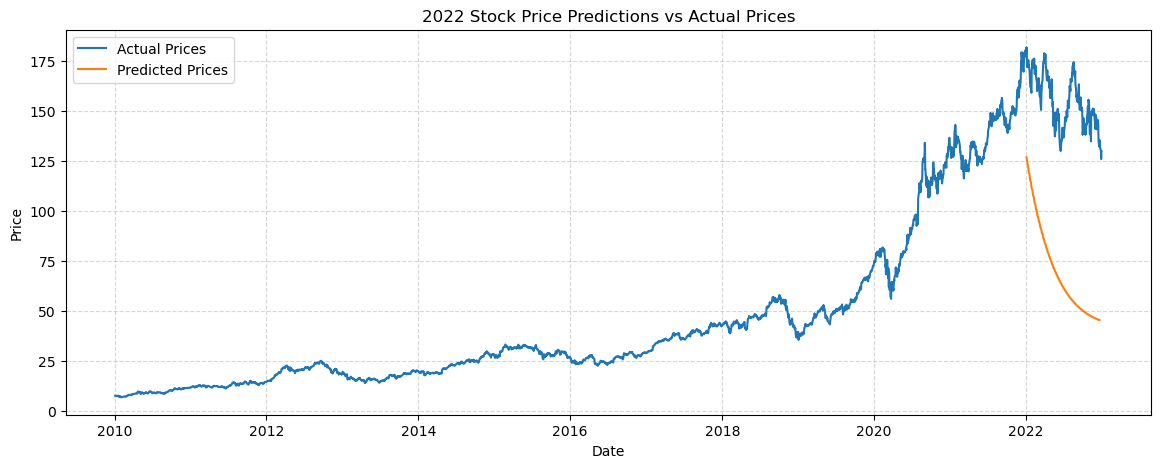

In [155]:
# Plotting the 2022 predictions
plt.figure(figsize=(14, 5))
plt.plot(apple_data.index, apple_data['Close'], label='Actual Prices')
plt.plot(pd.date_range(start='2022-01-01', periods=len(predictions), freq='B'), predictions, label='Predicted Prices')
plt.legend()
plt.title('2022 Stock Price Predictions vs Actual Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()





In [156]:
# Extract actual prices for 2022
actual_2022 = apple_data['Close']['2022-01-01':'2022-12-31'].values

# Ensure both arrays are the same length
if len(actual_2022) > len(predictions):
    actual_2022 = actual_2022[:len(predictions)]
elif len(actual_2022) < len(predictions):
    predictions = predictions[:len(actual_2022)]

# Calculate RMSE for 2022 predictions
rmse_2022 = np.sqrt(mean_squared_error(actual_2022, predictions))
print(f'2022 RMSE: {rmse_2022:.3f}')

# Calculate MAE for 2022 predictions
mae_2022 = mean_absolute_error(actual_2022, predictions)
print(f'2022 MAE: {mae_2022:.3f}')

# Calculate MAPE for 2022 predictions
mape_2022 = mean_absolute_percentage_error(actual_2022, predictions)
print(f'2022 MAPE: {mape_2022:.3%}')


2022 RMSE: 86.525
2022 MAE: 84.797
2022 MAPE: 55.244%


### 2022 Predictions Interpetation and Evaluation

The LSTM model’s predictions for Apple’s stock prices in 2022 reveal significant underestimations. The model struggles to adapt to sudden changes and fluctuations, which were less prevalent in the training data. In comparing the evaluation metrics from 2021 to 2022, the errors increase significantly 2022 AAPL stock prediction.

Throughout 2022, the model consistently predicts lower prices compared to the actual stock prices, similar to 2021 stock predictions. The stock market experienced sharp and unpredictable fluctuations starting around the onset of the COVID-19 pandemic in the first quarter of 2020. This high volatility contrasts with the more stable periods in the training data (2010-2020), which could be a factor in significant prediction errors. The pandemic brought unprecedented economic conditions, including lockdowns, shifts in consumer behavior, and rapid technological adoption, contributing to volatility and sudden changes in stock prices. The model appears to struggle to predict the stock shifts accurately. Additionally, the models training data ends in 2020, excluding the entire year of 2021. This exclusion limits the model’s ability to learn from recent market conditions that could have better informed its predictions for 2022. This shows the importance of using the most recent and relevant information to make better predictions.

The evaluation metrics for 2022 highlight the model’s performance challenges. The RMSE of 86.525 indicates substantial prediction errors, with the model’s predicted prices deviating significantly from the actual stock prices. The MAE of 84.797 further highlights the average absolute error in the model’s predictions. The MAPE of 55.244% suggests significant percentage errors potentially caused by the model's inability to handle rapid changes and volatility in stock prices during 2022.

In conclusion, the LSTM model shows limitations in predicting Apple’s stock prices for 2022 and did not perform very well overall. Potentially caused by market volatility, limited features included, and the exclusion of the entire year of 2021 from the training data.

### Recommendations for Improvements and Future Work

1. **Incorporate More Features**: Currently, the model uses only the closing price. Incorporating additional features such as opening price, high price, low price, volume, etc., could provide the model with more information, potentially improving its accuracy.

2. **Parameter Tuning and Alternative Optimizers**: Adjusting model parameters, such as the number of layers, number of neurons in each layer, dropout rates, and learning rate, can impact the performance of the LSTM model. Experimenting with different parameters and optimizers like RMSprop or Adamax, which are known for adapting learning rates and potentially improving performance, could yield better results.

3. **Evaluate on Less Volatile Data**: Testing the model on a stock that did not experience such volatility, or predicting Apple stock prices for years like 2018 or 2019, before the volatility occured could help in understanding the model's performance under more stable conditions.

4. **Extended Time Series Analysis**: Using methods like rolling windows and expanding windows can help in understanding how the model performs over different time frames and market conditions.

5. **Avoid Splitting Data for Time Series**: For time series data, it is crucial to ensure the temporal order of the data. Using a chronological split where the training set includes data up to the end of 2020 and the testing set includes data for 2021 would be more appropriate. This method allows the model to be trained on historical data and tested on future data, reflecting real-world forecasting scenarios more accurately.

### Questions for Consideration

Partitioning Data for Stock Prices:

    
For time series data like stock prices, should we always maintain the temporal order of the data instead of using a random split?
Would a chronological split (training up to 2020 and testing on 2021 and 2022) be more appropriate to ensure the model is trained on historical data and tested on future data, accurately reflecting real-world forecasting scenarios? https://arxiv.org/pdf/2307.14294

Predictions for 2022:

I am a little confused about whether the assignment is asking to predict stock prices for two calendar years (2021 and 2022) directly from a model trained up to 2020, or if the model should be updated with 2021 data before making predictions for 2022.
If updating the model with 2021 data is required, would it be appropriate to retrain the model with data up to the end of 2021 before predicting for 2022 to reflect more recent market conditions?



## Helpful Links

[1] Botache, D., Dingel, K., Huhnstock, R., Ehresmann, A., & Sick, B. (2023). Unraveling the complexity of splitting sequential data: Tackling challenges in video and time series analysis. Abstract. https://arxiv.org/pdf/2307.14294

[2] Jahan, I. (2018). Stock price prediction using recurrent neural networks. https://hdl.handle.net/10365/28797

[3] Montaño, J., Palmer, A., Sesé, A., & Cajal, B. (2013). Using the R-MAPE index as a resistant measure of forecast accuracy. Psicothema, 25, 500-506. https://doi.org/10.7334/psicothema2013.23

[4] Yahoo Finance API. (n.d.). Yahoo Finance API. https://pypi.org/project/yfinance/

[5] Zhu, Y. (2020). Stock price prediction using the RNN model. Journal of Physics: Conference Series, 1650(3), 032103. https://doi.org/10.1088/1742-6596/1650/3/032103